# Libraries and Data

In [ ]:
import geopandas as gpd
import branca.colormap as cm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as mpcm
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
import numpy as np
import pandas as pd

In [ ]:


# Load the traffic volume GeoJSON
gdf = gpd.read_file("yearly_traffic_volume_layers_2602944522563934822.geojson")
print(gdf.shape)
gdf[["route_id", "street_name", "num_aadt", "num_lanes", "posted_speed", "nfc_name"]].head()


(1427, 19)


,route_id,street_name,num_aadt,num_lanes,posted_speed,nfc_name
0,802803,8 Mile Rd E,54905,4.0,40,Other principal arterial
1,802803,8 Mile Rd E,37940,4.0,40,Other principal arterial
2,802803,8 Mile Rd E,39725,4.0,40,Other principal arterial
3,1576405,I 94,126670,6.0,55,Interstate
4,1576405,I 94,119706,6.0,55,Interstate


## Traffic Density Processing

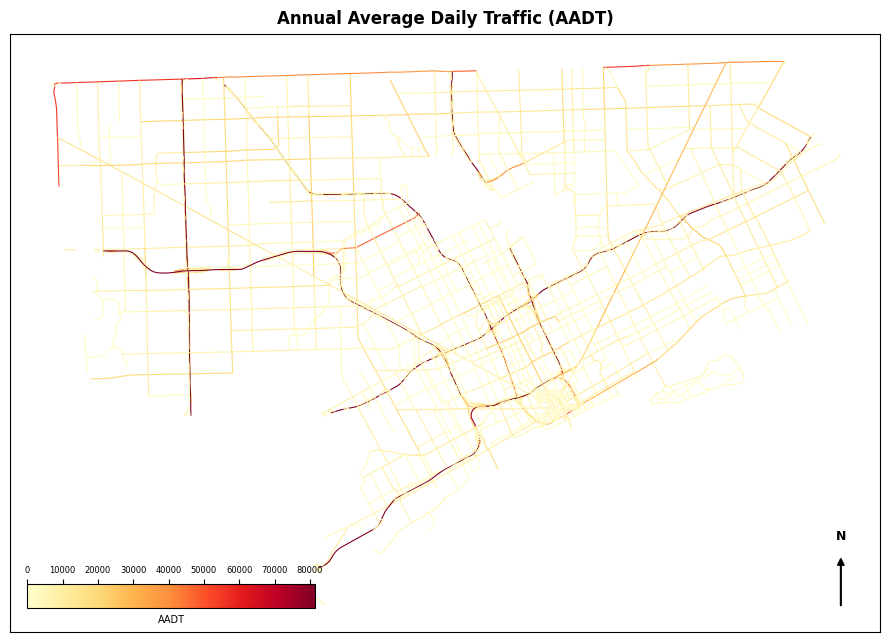

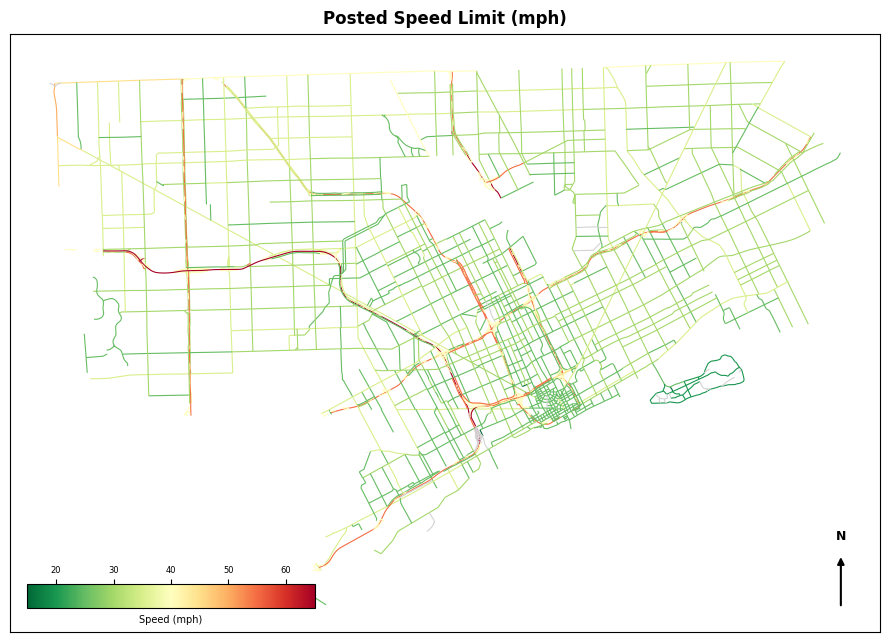

/var/folders/5z/7y4fq24d761794_v8h19r9xh0000gn/T/ipykernel_5081/1211379652.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(categories))


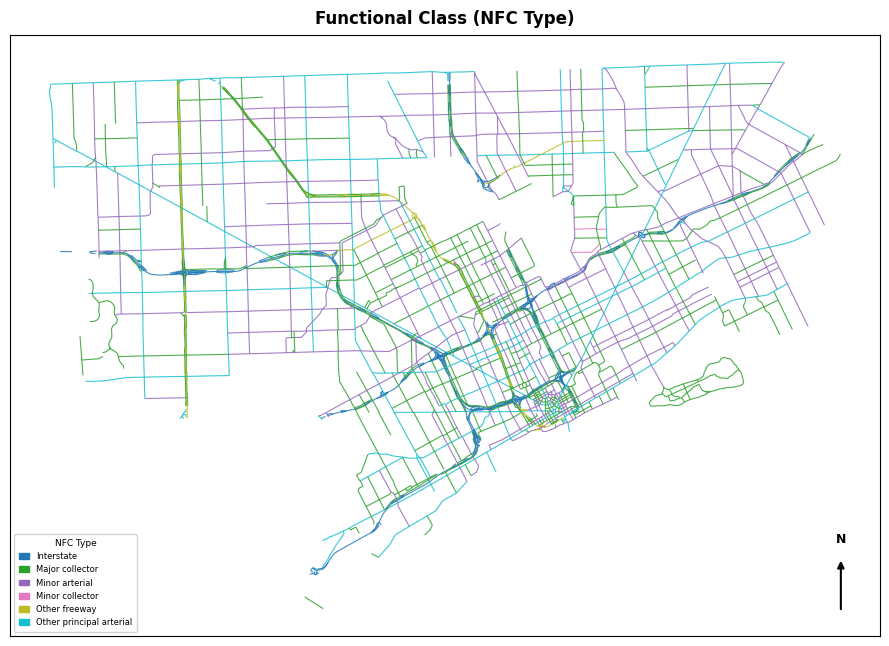

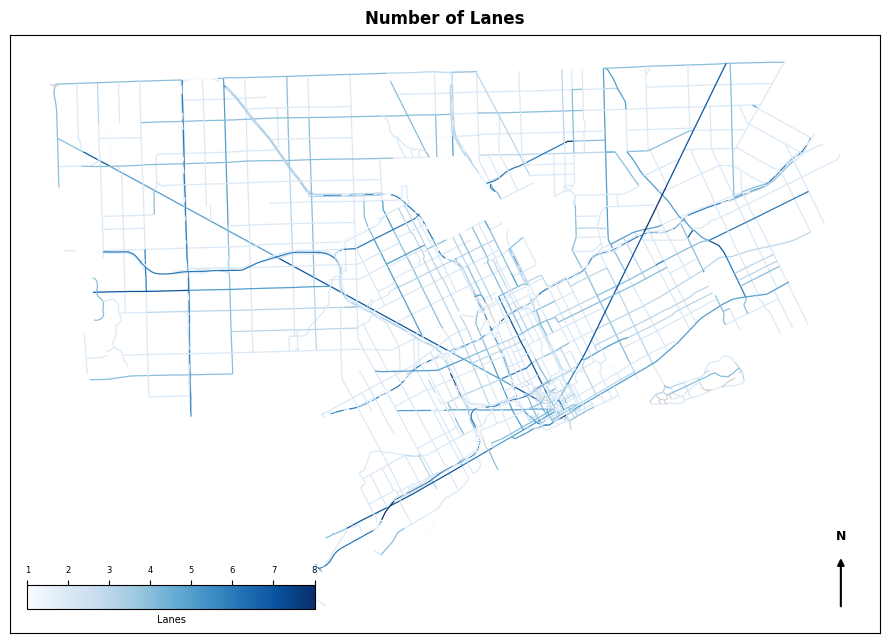

Saved → map_aadt.png  map_speed.png  map_nfc.png  map_lanes.png


In [ ]:
gdf_plot = gdf.copy()
gdf_plot["posted_speed_num"] = pd.to_numeric(gdf_plot["posted_speed"], errors="coerce")

FIG_W, FIG_H = 9, 7

def add_north_arrow(ax):
    """North arrow — bottom-right."""
    ax.annotate("", xy=(0.955, 0.13), xytext=(0.955, 0.04),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))
    ax.text(0.955, 0.15, "N", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=9, fontweight="bold")

def add_colorbar(ax, cmap, vmin, vmax, label):
    """Inset colorbar — 1/3 plot width, bottom-left."""
    cax = ax.inset_axes([0.02, 0.04, 0.33, 0.04])
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cb = ColorbarBase(cax, cmap=plt.get_cmap(cmap), norm=norm,
                      orientation="horizontal")
    cb.set_label(label, fontsize=7)
    cb.ax.tick_params(labelsize=6, which="both", bottom=False, labelbottom=False,
                      top=True, labeltop=True)

def style_ax(ax, title):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    ax.set_xticks([])
    ax.set_yticks([])

# ── 1. AADT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
vmax_aadt = gdf_plot["num_aadt"].quantile(0.95)
gdf_plot.plot(ax=ax, column="num_aadt", cmap="YlOrRd",
              linewidth=0.8, vmin=0, vmax=vmax_aadt, legend=False)
style_ax(ax, "Annual Average Daily Traffic (AADT)")
add_colorbar(ax, "YlOrRd", 0, int(vmax_aadt), "AADT")
add_north_arrow(ax)
plt.tight_layout()
plt.savefig("map_aadt.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Posted Speed ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
vmin_spd = gdf_plot["posted_speed_num"].min()
vmax_spd = gdf_plot["posted_speed_num"].max()
gdf_plot.plot(ax=ax, column="posted_speed_num", cmap="RdYlGn_r",
              linewidth=0.8, legend=False,
              missing_kwds={"color": "lightgrey"})
style_ax(ax, "Posted Speed Limit (mph)")
add_colorbar(ax, "RdYlGn_r", vmin_spd, vmax_spd, "Speed (mph)")
add_north_arrow(ax)
plt.tight_layout()
plt.savefig("map_speed.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. NFC Type (categorical) — use gdf.plot() so aspect matches other maps ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
categories = sorted(gdf_plot["nfc_name"].dropna().unique())
palette = plt.cm.get_cmap("tab10", len(categories))
cat_colors = {c: palette(i) for i, c in enumerate(categories)}

gdf_plot.plot(ax=ax, column="nfc_name", categorical=True,
              cmap="tab10", linewidth=0.8, alpha=0.85, legend=False)

patches = [mpatches.Patch(color=cat_colors[c], label=c) for c in categories]
ax.legend(handles=patches, fontsize=6, loc="lower left",
          framealpha=0.85, title="NFC Type", title_fontsize=6.5,
          borderpad=0.6, handlelength=1.2,
          bbox_to_anchor=(0.0, 0.0))
style_ax(ax, "Functional Class (NFC Type)")
add_north_arrow(ax)
plt.tight_layout()
plt.savefig("map_nfc.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Number of Lanes ───────────────────────────────────────────────────────
# NOTE: swap column="num_lanes" → column="ahf_per_m2" once you add:
#   gdf_plot["ahf_per_m2"] = gdf_plot["ahf_total"] / gdf_plot["road_area_m2"]
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
vmin_ln = gdf_plot["num_lanes"].min()
vmax_ln = gdf_plot["num_lanes"].max()
gdf_plot.plot(ax=ax, column="num_lanes", cmap="Blues",
              linewidth=0.9, legend=False,
              missing_kwds={"color": "lightgrey"})
style_ax(ax, "Number of Lanes")
add_colorbar(ax, "Blues", vmin_ln, vmax_ln, "Lanes")
add_north_arrow(ax)
plt.tight_layout()
plt.savefig("map_lanes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved → map_aadt.png  map_speed.png  map_nfc.png  map_lanes.png")